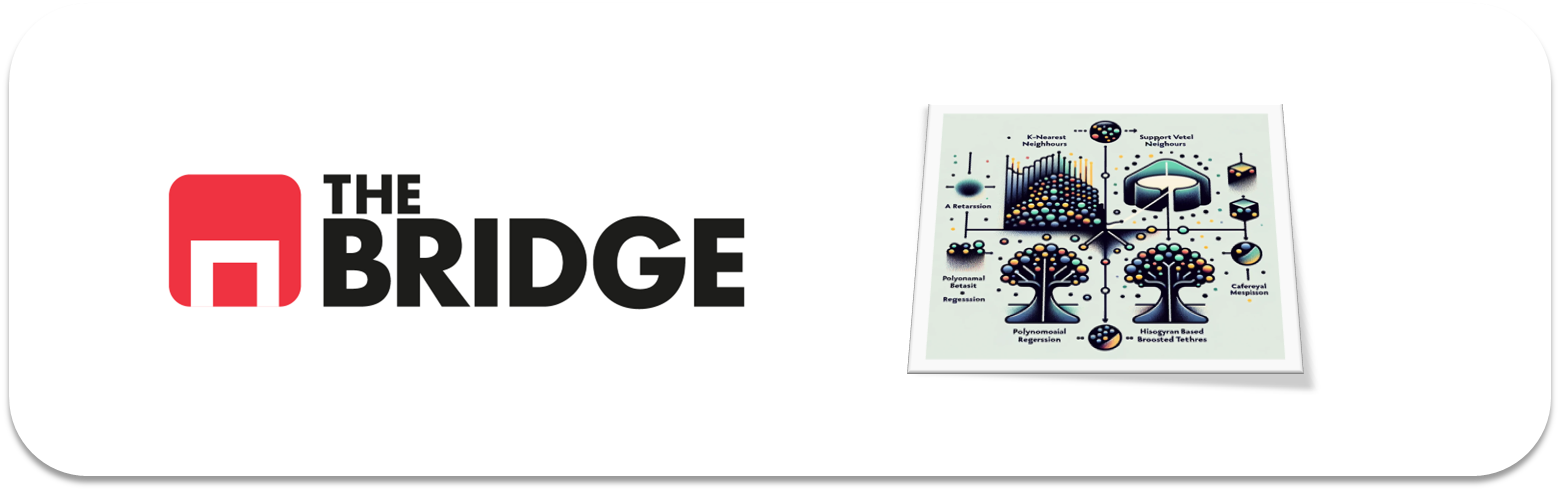

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)
from imblearn.over_sampling import SMOTE

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [2]:
# Cargamos el dataset
df = pd.read_csv("data/wines_dataset.csv")

# Primeras filas
print(df.head())
print("\n")

# Información general
print(df.info())

  fixed acidity|volatile acidity|citric acid|residual sugar|chlorides|free sulfur dioxide|total sulfur dioxide|density|pH|sulphates|alcohol|quality|class
0  8.5|0.21|0.26|9.25|0.034|73.0|142.0|0.9945|3.0...                                                                                                     
1  8.3|0.16|0.37|7.9|0.025|38.0|107.0|0.99306|2.9...                                                                                                     
2  6.8|0.18|0.38|1.4|0.038|35.0|111.0|0.9918|3.32...                                                                                                     
3  6.1|0.26|0.25|2.9|0.047|289.0|440.0|0.99314|3....                                                                                                     
4  7.5|0.63|0.27|2.0|0.083|17.0|91.0|0.99616|3.26...                                                                                                     


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496


In [3]:
# Cargamos el dataset con el separador correcto
df = pd.read_csv("data/wines_dataset.csv", sep="|")

# Primeras filas
print(df.head())
print("\n")

# Información general
print(df.info())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            8.5              0.21         0.26            9.25      0.034   
1            8.3              0.16         0.37            7.90      0.025   
2            6.8              0.18         0.38            1.40      0.038   
3            6.1              0.26         0.25            2.90      0.047   
4            7.5              0.63         0.27            2.00      0.083   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 73.0                 142.0  0.99450  3.05       0.37   
1                 38.0                 107.0  0.99306  2.93       0.37   
2                 35.0                 111.0  0.99180  3.32       0.59   
3                289.0                 440.0  0.99314  3.44       0.64   
4                 17.0                  91.0  0.99616  3.26       0.58   

   alcohol  quality  class  
0     11.4        6  white  
1     11.9        6  white  

El dataset Wine Quality contiene 6497 muestras de vinos portugueses "Vinho Verde" 
(tintos y blancos) con 11 características fisicoquímicas, una puntuación de calidad 
y la clase (tinto/blanco).

**Target 1 — Clasificación:** `quality` — puntuación de calidad entre 0 y 10 otorgada 
por catadores profesionales. El objetivo es predecir la clase de calidad de un vino 
a partir de sus propiedades químicas. Métrica objetivo: macro recall.

**Target 2 — Regresión:** `alcohol` — grado alcohólico del vino. El objetivo es 
predecir el porcentaje de alcohol a partir del resto de propiedades. 
Métrica objetivo: MAPE (error porcentual medio).

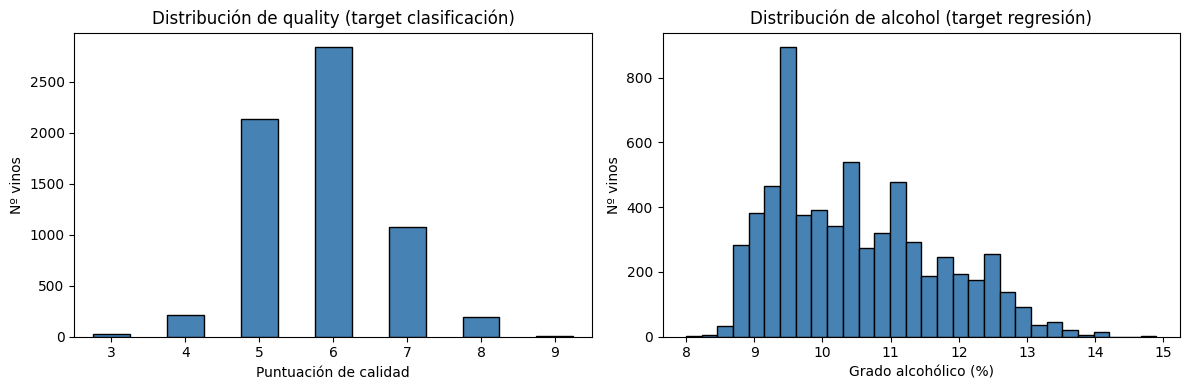

Distribución de quality:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

Estadísticas de alcohol:
count    6497.00
mean       10.49
std         1.19
min         8.00
25%         9.50
50%        10.30
75%        11.30
max        14.90
Name: alcohol, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribución de quality (clasificación)
df["quality"].value_counts().sort_index().plot(kind="bar", ax=axes[0], 
                                                color="steelblue", edgecolor="black")
axes[0].set_title("Distribución de quality (target clasificación)")
axes[0].set_xlabel("Puntuación de calidad")
axes[0].set_ylabel("Nº vinos")
axes[0].tick_params(axis='x', rotation=0)

# Distribución de alcohol (regresión)
df["alcohol"].plot(kind="hist", ax=axes[1], bins=30, color="steelblue", edgecolor="black")
axes[1].set_title("Distribución de alcohol (target regresión)")
axes[1].set_xlabel("Grado alcohólico (%)")
axes[1].set_ylabel("Nº vinos")

plt.tight_layout()
plt.show()

print("Distribución de quality:")
print(df["quality"].value_counts().sort_index())
print("\nEstadísticas de alcohol:")
print(df["alcohol"].describe().round(2))

### Problema 1 — Clasificación (quality)
El target tiene 7 clases (3 a 9) con un desbalance muy marcado: las clases 5 y 6 
concentran el 76% de los vinos, mientras que las clases extremas (3, 4, 8, 9) 
tienen muy pocas muestras. Esto es un problema de clasificación multiclase desbalanceada.
El macro recall será difícil de optimizar en las clases extremas por la escasez de muestras.
Aplicaremos SMOTE para intentar compensar el desbalance.

### Problema 2 — Regresión (alcohol)
El grado alcohólico va de 8% a 14.9%, con una media de 10.49% y una distribución 
ligeramente asimétrica con dos picos (uno en torno a 9.5% y otro en torno a 11%). 
No hay valores extremos problemáticos. La métrica objetivo es el MAPE 
(error porcentual medio) — cuanto más bajo mejor.

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [5]:
# Definimos X e y para clasificación
# Quitamos alcohol (será target en regresión) y quality (target aquí)
X_clf = df.drop(columns=["quality", "alcohol"])
y_clf = df["quality"]

# Encoding de la variable class (white/red)
X_clf["class"] = X_clf["class"].map({"white": 0, "red": 1})

# Split estratificado por quality
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("X_train:", X_train_clf.shape)
print("X_test:", X_test_clf.shape)
print("\nDistribución quality en train:")
print(y_train_clf.value_counts().sort_index())

X_train: (5197, 11)
X_test: (1300, 11)

Distribución quality en train:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64


In [7]:
# Escalado
scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)

# SMOTE para balancear las clases
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_clf_bal, y_train_clf_bal = smote.fit_resample(X_train_clf_scaled, y_train_clf)

print("Distribución tras SMOTE:")
print(y_train_clf_bal.value_counts().sort_index())

Distribución tras SMOTE:
quality
3    2269
4    2269
5    2269
6    2269
7    2269
8    2269
9    2269
Name: count, dtype: int64


In [8]:
# Definimos los modelos — KNN como baseline con dos valores de K
knn3 = KNeighborsClassifier(n_neighbors=3)
knn7 = KNeighborsClassifier(n_neighbors=7)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# Comparamos con cross validation (5 folds, macro recall)
modelos = {
    "KNN k=3": knn3,
    "KNN k=7": knn7,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

for nombre, modelo in modelos.items():
    scores = cross_val_score(modelo, X_train_clf_bal, y_train_clf_bal, cv=5, scoring="recall_macro")
    print(f"{nombre}: recall medio = {scores.mean():.3f} (+/- {scores.std():.3f})")

KNN k=3: recall medio = 0.858 (+/- 0.021)
KNN k=7: recall medio = 0.818 (+/- 0.020)
Random Forest: recall medio = 0.898 (+/- 0.015)
Gradient Boosting: recall medio = 0.759 (+/- 0.018)


### Comparación de modelos con Cross Validation (Clasificación)

| Modelo | Recall medio | Desviación |
|---|---|---|
| KNN k=3 | 0.858 | +/- 0.021 |
| KNN k=7 | 0.818 | +/- 0.020 |
| Random Forest | 0.898 | +/- 0.015 |
| Gradient Boosting | 0.759 | +/- 0.018 |

**Modelo seleccionado: Random Forest** — mejor recall medio y mayor estabilidad.
KNN k=3 supera a KNN k=7 — valores de K pequeños funcionan mejor en este dataset.
Gradient Boosting es el peor, probablemente porque con 7 clases y dataset grande 
tarda más en converger con parámetros por defecto.

In [9]:
# Grid de hiperparámetros
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 5, 10],
}

# GridSearchCV optimizando macro recall
grid_search_clf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="recall_macro",
    n_jobs=-1,
    verbose=1
)

grid_search_clf.fit(X_train_clf_bal, y_train_clf_bal)

print("Mejores hiperparámetros:", grid_search_clf.best_params_)
print("Mejor recall macro en CV:", grid_search_clf.best_score_.round(3))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Mejor recall macro en CV: 0.899


=== RANDOM FOREST OPTIMIZADO - TEST (CLASIFICACIÓN) ===
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.27      0.37      0.31        43
           5       0.73      0.72      0.72       428
           6       0.69      0.66      0.67       567
           7       0.57      0.61      0.59       216
           8       0.40      0.41      0.41        39
           9       0.00      0.00      0.00         1

    accuracy                           0.65      1300
   macro avg       0.38      0.40      0.39      1300
weighted avg       0.66      0.65      0.65      1300



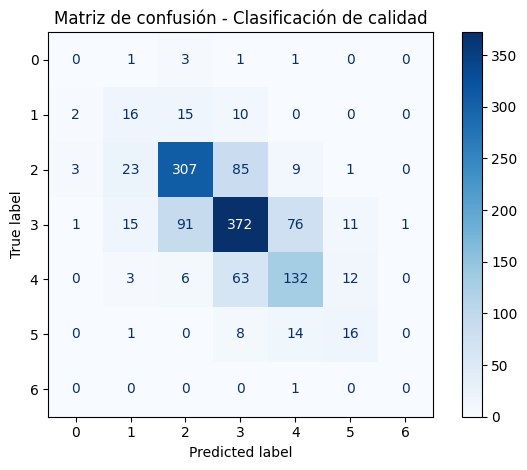

In [10]:
# Evaluamos el modelo optimizado contra test
best_rf_clf = grid_search_clf.best_estimator_

y_pred_clf = best_rf_clf.predict(X_test_clf_scaled)

print("=== RANDOM FOREST OPTIMIZADO - TEST (CLASIFICACIÓN) ===")
print(classification_report(y_test_clf, y_pred_clf))

# Matriz de confusión
ConfusionMatrixDisplay(confusion_matrix(y_test_clf, y_pred_clf)).plot(cmap="Blues")
plt.title("Matriz de confusión - Clasificación de calidad")
plt.tight_layout()
plt.show()

### Evaluación y análisis de errores — Clasificación

**Macro recall en test: 0.40** — caída importante respecto al CV (0.899),
el modelo aprende bien los datos sintéticos pero en test aparece el desbalance real.

**Por clases:**
- Clases 5 y 6 (las mayoritarias): buen resultado, recall 0.72 y 0.66
- Clase 7: recall 0.61, aceptable
- Clases 3 y 9: recall 0.00 — el modelo no detecta ningún vino de calidad extrema. 
  Con solo 6 y 1 muestras en test respectivamente, era previsible.
- Clase 4: recall 0.37, débil pero algo aprende

**Matriz de confusión:** los errores se concentran entre clases adyacentes 
(5↔6, 6↔7) — el modelo confunde calidades cercanas, lo cual es razonable 
ya que la diferencia entre un vino de calidad 5 y uno de calidad 6 
es subjetiva incluso para catadores humanos.

**Propuestas de mejora:**
- Agrupar las clases extremas (3-4 → "baja calidad", 5-6 → "media", 7-9 → "alta") 
  reduciría el problema a 3 clases más equilibradas y probablemente mejoraría el recall.
- Aumentar el dataset con más muestras de clases extremas.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

In [11]:
# Definimos X e y para regresión
# Ahora alcohol es el target y quality se incluye como feature
X_reg = df.drop(columns=["alcohol"])
y_reg = df["alcohol"]

# Encoding de la variable class (white/red)
X_reg["class"] = X_reg["class"].map({"white": 0, "red": 1})

# Split estratificado no aplica en regresión — split normal
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Escalado
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("X_train:", X_train_reg.shape)
print("X_test:", X_test_reg.shape)

X_train: (5197, 12)
X_test: (1300, 12)


In [12]:
from sklearn.metrics import make_scorer

# Definimos los modelos de regresión
lr = LinearRegression()
rf_reg = RandomForestRegressor(random_state=42)
gb_reg = GradientBoostingRegressor(random_state=42)

# Comparamos con cross validation (5 folds, MAPE negativo)
# neg porque sklearn minimiza, y MAPE queremos minimizarlo
modelos_reg = {
    "Regresión Lineal": lr,
    "Random Forest": rf_reg,
    "Gradient Boosting": gb_reg
}

for nombre, modelo in modelos_reg.items():
    scores = cross_val_score(modelo, X_train_reg_scaled, y_train_reg, 
                             cv=5, scoring="neg_mean_absolute_percentage_error")
    print(f"{nombre}: MAPE medio = {(-scores.mean()):.3f} (+/- {scores.std():.3f})")

Regresión Lineal: MAPE medio = 0.034 (+/- 0.001)
Random Forest: MAPE medio = 0.027 (+/- 0.001)
Gradient Boosting: MAPE medio = 0.035 (+/- 0.001)


### Comparación de modelos con Cross Validation (Regresión)

| Modelo | MAPE medio | Desviación |
|---|---|---|
| Regresión Lineal | 0.034 | +/- 0.001 |
| Random Forest | 0.027 | +/- 0.001 |
| Gradient Boosting | 0.035 | +/- 0.001 |

**Modelo seleccionado: Random Forest** — menor MAPE medio (2.7% de error porcentual) 
y máxima estabilidad. Los tres modelos son muy buenos — un error del 3% en grado 
alcohólico es excelente. Random Forest supera incluso a Gradient Boosting, 
probablemente porque las relaciones entre variables fisicoquímicas y alcohol 
no son estrictamente lineales ni secuenciales.

In [13]:
# Grid de hiperparámetros
param_grid_reg = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_leaf": [1, 5, 10],
}

# GridSearchCV optimizando MAPE
grid_search_reg = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_reg,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs=-1,
    verbose=1
)

grid_search_reg.fit(X_train_reg_scaled, y_train_reg)

print("Mejores hiperparámetros:", grid_search_reg.best_params_)
print("Mejor MAPE en CV:", (-grid_search_reg.best_score_).round(3))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 300}
Mejor MAPE en CV: 0.027


=== RANDOM FOREST OPTIMIZADO - TEST (REGRESIÓN) ===
MAPE: 0.025 (2.5%)
RMSE: 0.401
R²: 0.886


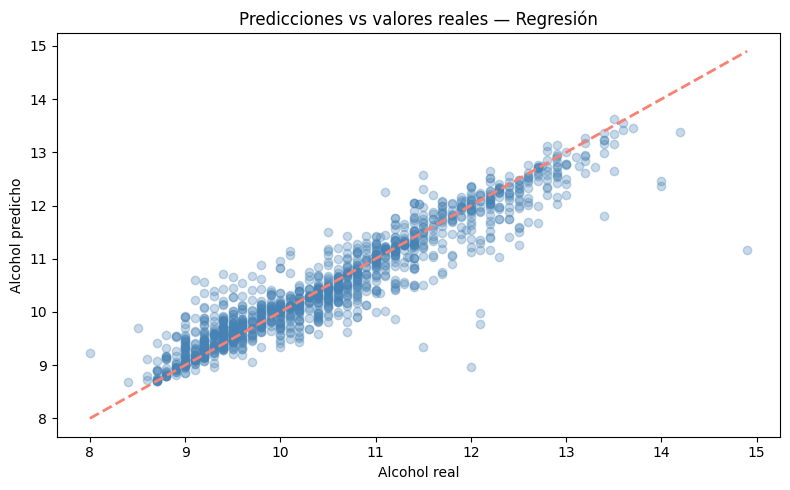

In [15]:
from sklearn.metrics import root_mean_squared_error

# Métricas de regresión
mape = mean_absolute_percentage_error(y_test_reg, y_pred_reg)
rmse = root_mean_squared_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== RANDOM FOREST OPTIMIZADO - TEST (REGRESIÓN) ===")
print(f"MAPE: {mape:.3f} ({mape*100:.1f}%)")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

# Gráfico de predicciones vs valores reales
plt.figure(figsize=(8, 5))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, color="steelblue")
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         color="salmon", linestyle="--", linewidth=2)
plt.xlabel("Alcohol real")
plt.ylabel("Alcohol predicho")
plt.title("Predicciones vs valores reales — Regresión")
plt.tight_layout()
plt.show()

### Evaluación y análisis de errores — Regresión

**Métricas en test:**
- MAPE: 2.5% — el modelo se equivoca de media un 2.5% sobre el grado alcohólico real. 
  Para un vino de 10°, el error medio es de 0.25°. Excelente resultado.
- RMSE: 0.401 — el error medio en grados absolutos es de 0.4°.
- R²: 0.886 — el modelo explica el 88.6% de la varianza del grado alcohólico.

**Gráfico predicciones vs valores reales:** los puntos se alinean muy bien 
sobre la diagonal (línea perfecta), confirmando que el modelo generaliza correctamente. 
Se aprecian algunos outliers en valores extremos (>13°) donde el modelo tiende 
a subestimar ligeramente — probablemente por la escasez de muestras en esos rangos.

**Análisis de errores:** los mayores errores se concentran en vinos con grados 
alcohólicos extremos (por debajo de 9° y por encima de 13°), donde hay menos 
datos de entrenamiento. En el rango central (9°-12°) el modelo es muy preciso.

**Conclusión:** el problema de regresión resulta más sencillo que el de clasificación 
para este dataset. El grado alcohólico tiene una relación física directa con variables 
como la densidad y el azúcar residual, lo que facilita el aprendizaje del modelo.